# Comparaison 6 modèles — Dataset 1 Pump Maintenance — by_temporal_window

| Champ | Valeur |
|-------|--------|
| **Scénario** | by_temporal_window : Q1 (0–5k h) → Q2 (5k–10k h) → Q3 (10k–15k h) → Q4 (15k–20k h) — 4 tâches |
| **Modèles** | TinyOL · EWC · HDC · KMeans · Mahalanobis · DBSCAN |
| **Dataset** | Large_Industrial_Pump_Maintenance_Dataset.csv |
| **Sprint** | 8 — S8-14 |

Ce notebook agrège les résultats des expériences **exp_024, exp_025, exp_026, exp_028, exp_027, exp_029**.
Voir `notebooks/cl_eval/pump_by_pump_id/comparison.ipynb` pour le scénario by_pump_id.

**Figures générées** :
1. `radar_comparison.png` — radar 5-axes (AA, Stabilité, BWT, RAM, Vitesse)
2. `barplot_aa_comparison.png` — barplot AA/AF/BWT pour les 6 modèles
3. `acc_matrix_grid.png` — grille 2×3 des matrices d'accuracy 4×4
4. `scatter_ram_vs_accuracy.png` — trade-off RAM/performance (Gap 2, budget STM32 ≤ 64 Ko)
5. `scatter_flops_vs_accuracy.png` — coût de calcul portable (MACs, indépendant de la machine)
6. `scatter_latency_vs_accuracy.png` — latence PC (budget 100 ms, ⚠ non transférable au MCU)

In [1]:
# Section 1 — Setup + chargement normalisé des 6 modèles
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "pump_by_temporal_window":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_metrics_comparison, plot_model_radar, plot_performance_by_task_bar, save_figure,
)
from src.evaluation.compute_cost import compute_macs

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/comparison/pump/by_temporal_window"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES = [
    "Q1 (0–5k h)",
    "Q2 (5k–10k h)",
    "Q3 (10k–15k h)",
    "Q4 (15k–20k h)",
]
MODEL_ORDER = ["TinyOL", "EWC", "HDC", "KMeans", "Mahalanobis", "DBSCAN"]
N_TASKS = 4

MODEL_EXP_MAP = {
    "TinyOL":      ("exp_024_tinyol_pump_temporal",      "metrics.json",                      None),
    "EWC":         ("exp_025_ewc_pump_temporal",          "metrics.json",                      "acc_matrix_ewc.npy"),
    "HDC":         ("exp_026_hdc_pump_temporal",          "metrics.json",                      "acc_matrix_hdc.npy"),
    "KMeans":      ("exp_028_kmeans_pump_temporal",       "metrics_kmeans_dataset1.json",      "acc_matrix_kmeans_dataset1.npy"),
    "Mahalanobis": ("exp_027_mahalanobis_pump_temporal",  "metrics_mahalanobis_dataset1.json", "acc_matrix_mahalanobis_dataset1.npy"),
    "DBSCAN":      ("exp_029_dbscan_pump_temporal",       "metrics_dbscan_dataset1.json",      "acc_matrix_dbscan_dataset1.npy"),
}

BASE = REPO_ROOT / "experiments"
RAM_LIMIT = 64 * 1024  # bytes — contrainte STM32N6


def normalize_metrics(raw: dict, model_name: str) -> dict:
    """Normalise les différents schémas de metrics.json vers un dict commun.

    Clés retournées : aa, af, bwt, ram_peak_bytes, inference_latency_ms, n_params, auroc_avg.
    """
    if model_name == "TinyOL":
        return {
            "aa":  raw.get("acc_final", raw.get("aa", 0.0)),
            "af":  raw.get("avg_forgetting", raw.get("af", 0.0)),
            "bwt": raw.get("backward_transfer", raw.get("bwt", 0.0)),
            "ram_peak_bytes": raw.get("ram_peak_bytes", 0),
            "inference_latency_ms": raw.get("inference_latency_ms", 0.0),
            "n_params": raw.get("n_params_encoder", 184) + raw.get("n_params_oto", 10),
            "auroc_avg": raw.get("auroc_avg"),
        }
    if model_name == "EWC" and "cl_metrics" in raw:
        cl = raw["cl_metrics"].get("ewc", raw["cl_metrics"])
        mem = raw["cl_metrics"].get("memory", {}).get("forward", {})
        return {
            "aa": cl.get("aa", 0.0), "af": cl.get("af", 0.0), "bwt": cl.get("bwt", 0.0),
            "ram_peak_bytes": mem.get("ram_peak_bytes", raw.get("ram_peak_bytes", 0)),
            "inference_latency_ms": mem.get("inference_latency_ms", raw.get("inference_latency_ms", 0.0)),
            "n_params": mem.get("n_params", raw.get("n_params", 0)),
            "auroc_avg": raw.get("auroc_avg"),
        }
    if model_name == "HDC" and "cl_metrics" in raw:
        cl = raw["cl_metrics"]
        return {
            "aa": cl.get("aa", 0.0), "af": cl.get("af", 0.0), "bwt": cl.get("bwt", 0.0),
            "ram_peak_bytes": cl.get("ram_peak_bytes", 0),
            "inference_latency_ms": cl.get("inference_latency_ms", 0.0),
            "n_params": cl.get("n_params", 2048),
            "auroc_avg": cl.get("auroc_avg"),
        }
    if "cl_metrics" in raw:  # KMeans structure imbriquée
        cl = raw["cl_metrics"]
        mem = cl.get("memory", {})
        return {
            "aa": cl.get("aa", 0.0), "af": cl.get("af", 0.0), "bwt": cl.get("bwt", 0.0),
            "ram_peak_bytes": mem.get("ram_peak_bytes", 0),
            "inference_latency_ms": mem.get("inference_latency_ms", 0.0),
            "n_params": mem.get("n_params", 0),
            "auroc_avg": cl.get("auroc_avg"),
        }
    # Structure plate (Mahalanobis, DBSCAN, KMeans sans cl_metrics, EWC/HDC sans cl_metrics)
    mem = raw.get("memory", {})
    return {
        "aa":  raw.get("aa", raw.get("acc_final", 0.0)),
        "af":  raw.get("af", raw.get("avg_forgetting", 0.0)),
        "bwt": raw.get("bwt", raw.get("backward_transfer", 0.0)),
        "ram_peak_bytes": mem.get("ram_peak_bytes", raw.get("ram_peak_bytes", 0)),
        "inference_latency_ms": mem.get("inference_latency_ms", raw.get("inference_latency_ms", 0.0)),
        "n_params": mem.get("n_params", raw.get("n_params", 0)),
        "auroc_avg": raw.get("auroc_avg"),
    }


def load_acc_matrix(model_name: str, raw: dict, npy_file: str | None, exp_dir: Path) -> np.ndarray:
    """Charge la matrice d'accuracy N×N — npy en priorité, puis acc_matrix du JSON, puis NaN."""
    if npy_file is not None:
        npy_path = exp_dir / npy_file
        if npy_path.exists():
            return np.array(np.load(npy_path, allow_pickle=True), dtype=float)
    # Lecture depuis le JSON (tous les modèles qui stockent acc_matrix inline)
    if "acc_matrix" in raw:
        raw_mat = raw["acc_matrix"]
        n = len(raw_mat)
        mat = np.full((n, n), np.nan, dtype=float)
        for i, row in enumerate(raw_mat):
            for j, v in enumerate(row):
                if v is not None:
                    mat[i, j] = v
        return mat
    return np.full((N_TASKS, N_TASKS), np.nan, dtype=float)


# Chargement des 6 modèles (avec fallback mock)
results = {}
acc_matrices = {}

for model in MODEL_ORDER:
    exp_dir_name, metrics_file, npy_file = MODEL_EXP_MAP[model]
    exp_dir = BASE / exp_dir_name / "results"
    m_path = exp_dir / metrics_file
    if m_path.exists():
        raw = json.loads(m_path.read_text())
        results[model] = normalize_metrics(raw, model)
        acc_matrices[model] = load_acc_matrix(model, raw, npy_file, exp_dir)
    else:
        print(f"[MOCK] {model} : {exp_dir_name} non trouvé — valeurs mock utilisées")
        results[model] = {
            "aa": 0.5, "af": 0.0, "bwt": 0.0,
            "ram_peak_bytes": 0, "inference_latency_ms": 0.0,
            "n_params": 0, "auroc_avg": None,
        }
        acc_matrices[model] = np.full((N_TASKS, N_TASKS), 0.5)

    r = results[model]
    auroc_s = f"{r['auroc_avg']:.4f}" if isinstance(r['auroc_avg'], float) else "—"
    print(f"{model:12s} → AA={r['aa']:.4f} AF={r['af']:.4f} BWT={r['bwt']:+.4f} "
          f"RAM={r['ram_peak_bytes']/1024:5.1f}Ko lat={r['inference_latency_ms']:.5f}ms "
          f"n_params={r['n_params']} AUROC={auroc_s}")

print(f"\n6 modèles chargés | Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

TinyOL       → AA=0.5694 AF=0.0086 BWT=-0.0086 RAM=  5.7Ko lat=0.01193ms n_params=1506 AUROC=—
EWC          → AA=0.5121 AF=0.0054 BWT=+0.0000 RAM=  1.1Ko lat=0.03606ms n_params=1377 AUROC=—
HDC          → AA=0.4637 AF=0.0645 BWT=-0.0591 RAM= 14.2Ko lat=0.21850ms n_params=2048 AUROC=—
KMeans       → AA=0.4718 AF=0.0000 BWT=+0.0108 RAM=  5.7Ko lat=0.30108ms n_params=50 AUROC=0.4260
Mahalanobis  → AA=0.4839 AF=0.0215 BWT=+0.0161 RAM=  2.0Ko lat=0.00723ms n_params=650 AUROC=0.4625
DBSCAN       → AA=0.5121 AF=0.0000 BWT=+0.0000 RAM= 60.0Ko lat=0.41835ms n_params=6225 AUROC=0.4648

6 modèles chargés | Date exécution : 2026-04-22 11:25


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_temporal_window/radar_comparison.png


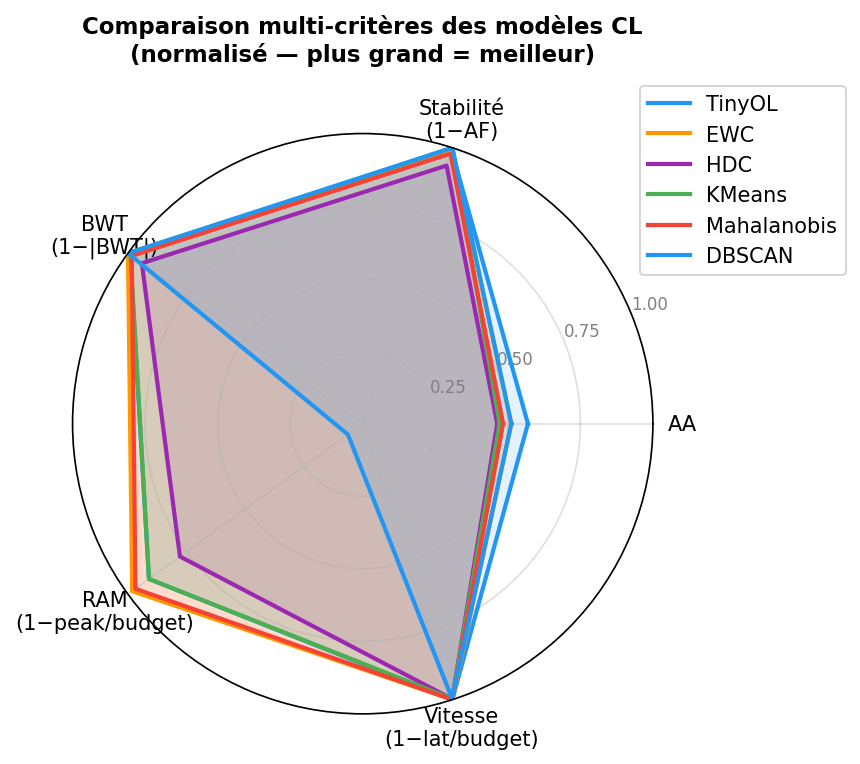

In [2]:
# Section 2 — Radar multi-critères (6 modèles, 5 axes normalisés)
# Axes : AA, Stabilité (1−AF), BWT neutre (1−|BWT|), RAM (1−peak/64Ko), Vitesse (1−lat/100ms)

fig = plot_model_radar(results, ram_budget_bytes=65536.0, latency_budget_ms=100.0)
save_figure(fig, FIGURES_DIR / "radar_comparison.png")
display(Image(str(FIGURES_DIR / "radar_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_temporal_window/barplot_aa_comparison.png


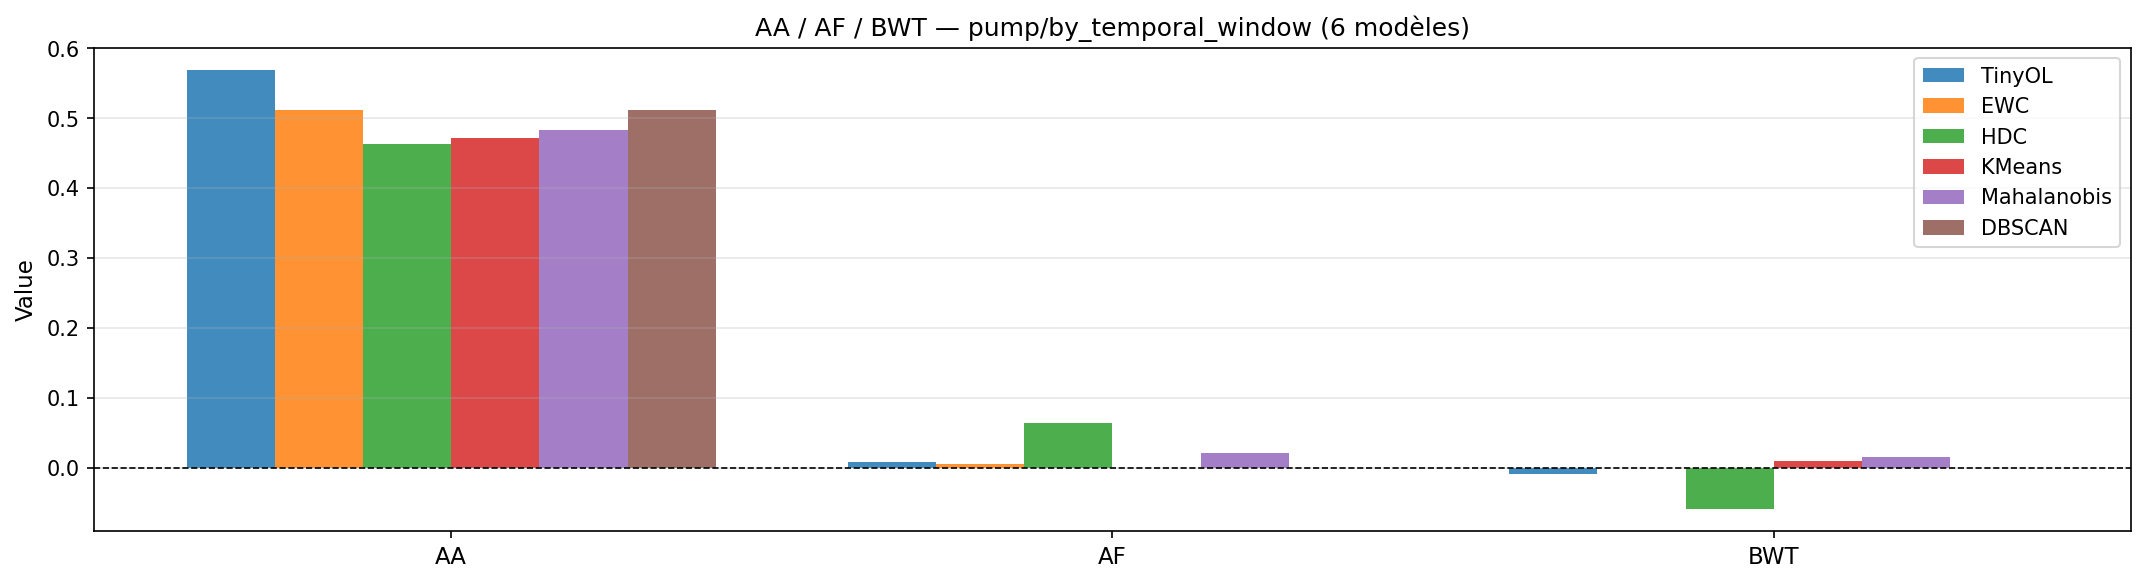

In [3]:
# Section 3 — Barplot AA/AF/BWT groupé (6 modèles)

fig = plot_metrics_comparison(
    results,
    metrics=["aa", "af", "bwt"],
    title="AA / AF / BWT — pump/by_temporal_window (6 modèles)",
)
save_figure(fig, FIGURES_DIR / "barplot_aa_comparison.png")
display(Image(str(FIGURES_DIR / "barplot_aa_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_temporal_window/acc_matrix_grid.png


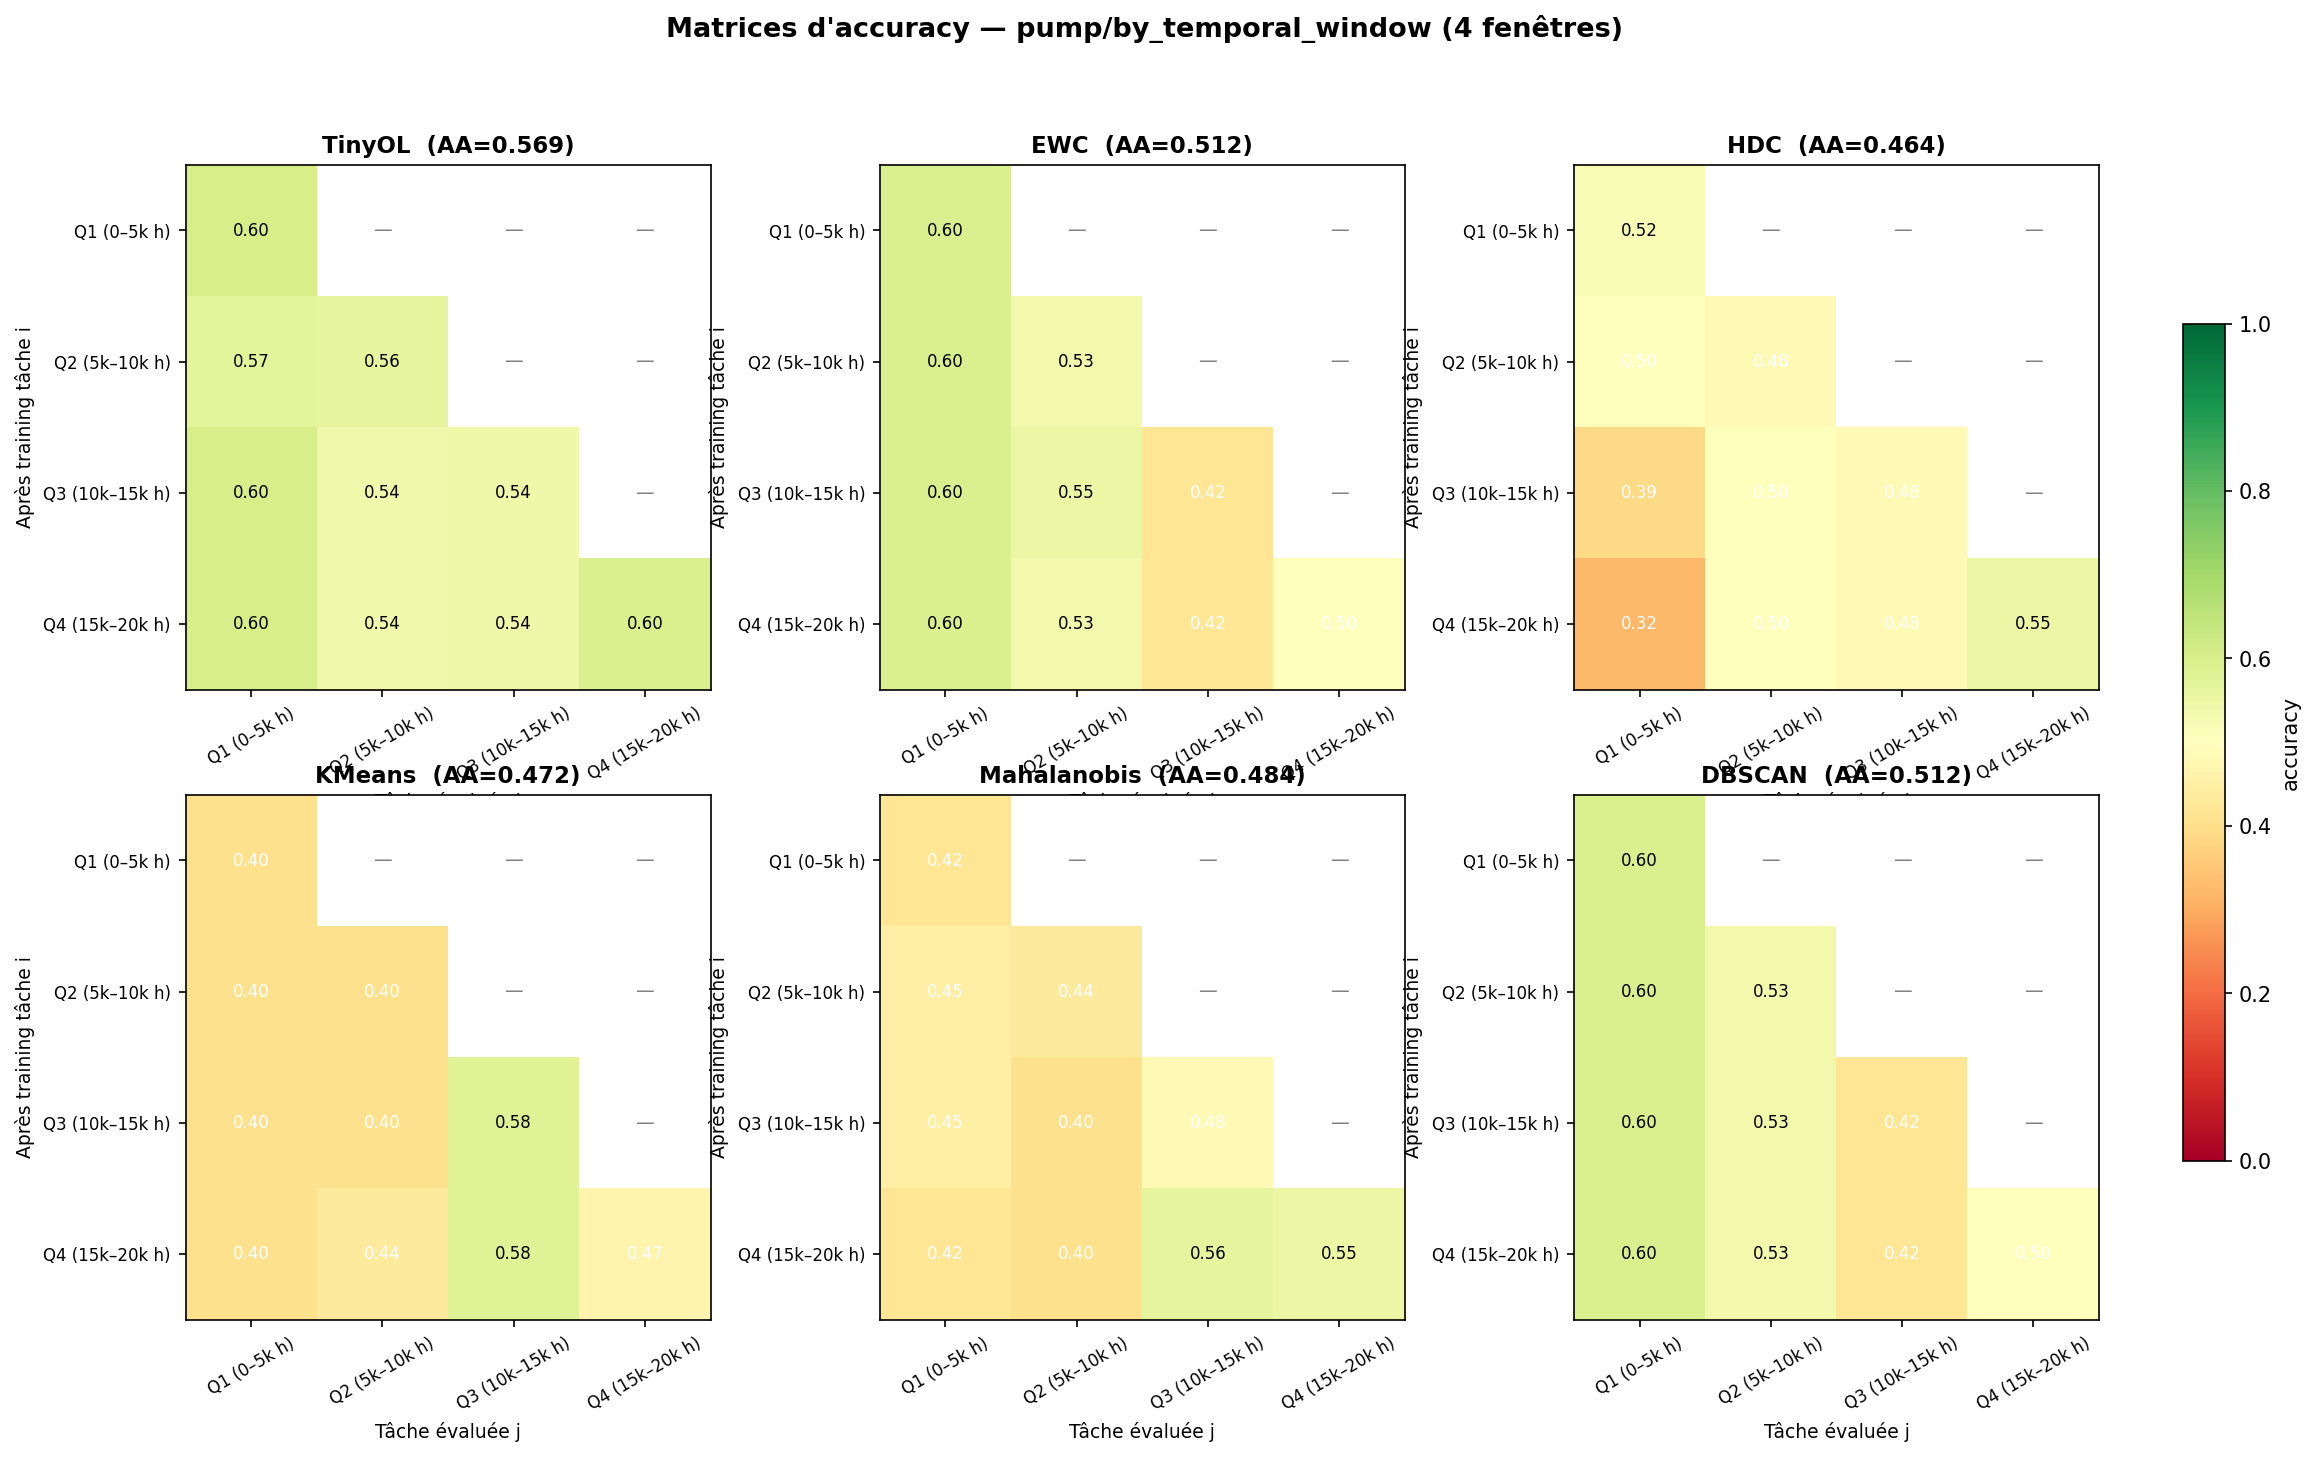

In [4]:
# Section 4 — Grille 2×3 des matrices d'accuracy 4×4 (4 fenêtres temporelles)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cmap = plt.get_cmap("RdYlGn")

for ax, model in zip(axes.flat, MODEL_ORDER):
    acc_mat = acc_matrices[model]
    masked = np.ma.masked_invalid(acc_mat)
    im = ax.imshow(masked, vmin=0, vmax=1, cmap=cmap)
    ax.set_title(f"{model}  (AA={results[model]['aa']:.3f})", fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(TASK_NAMES)))
    ax.set_yticks(range(len(TASK_NAMES)))
    ax.set_xticklabels(TASK_NAMES, rotation=30, fontsize=8)
    ax.set_yticklabels(TASK_NAMES, fontsize=8)
    ax.set_xlabel("Tâche évaluée j", fontsize=9)
    ax.set_ylabel("Après training tâche i", fontsize=9)
    for i in range(acc_mat.shape[0]):
        for j in range(acc_mat.shape[1]):
            v = acc_mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                        color="black" if v > 0.5 else "white")
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="grey")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04, label="accuracy")
fig.suptitle("Matrices d'accuracy — pump/by_temporal_window (4 fenêtres)", fontsize=13, fontweight="bold")
save_figure(fig, FIGURES_DIR / "acc_matrix_grid.png")
display(Image(str(FIGURES_DIR / "acc_matrix_grid.png")))

In [5]:
# Section 5 — Évolution de l'oubli sur T1 (Q1) au fil du temps (figure exploratoire, non sauvegardée)
# Visualise si les modèles "oublient" Q1 au fur et à mesure qu'ils apprennent Q2, Q3, Q4.

fig, ax = plt.subplots(figsize=(10, 6))

for model in MODEL_ORDER:
    acc_mat = acc_matrices[model]
    t1_over_time = acc_mat[:, 0]  # accuracy sur T1 après chaque tâche d'entraînement
    ax.plot(range(len(t1_over_time)), t1_over_time, marker="o", label=model)

ax.set_xlabel("Tâche d'entraînement courante", fontsize=11)
ax.set_ylabel("Accuracy sur T1 (Q1 : 0–5k heures)", fontsize=11)
ax.set_xticks(range(len(TASK_NAMES)))
ax.set_xticklabels(TASK_NAMES, rotation=30, ha="right")
ax.set_title("Oubli catastrophique T1 au fil du temps — comparaison 6 modèles",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

/tmp/ipykernel_68977/1835671592.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_temporal_window/scatter_ram_vs_accuracy.png


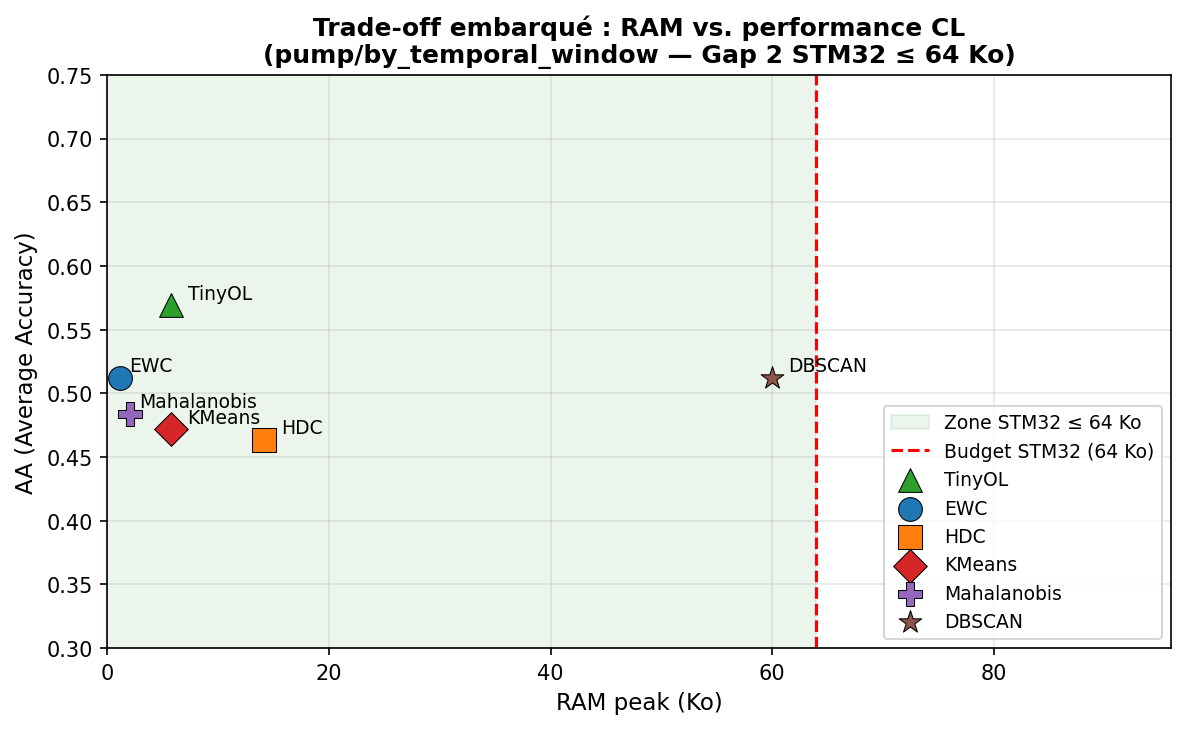

In [6]:
# Section 6a — Scatter RAM peak vs. accuracy (Gap 2 — STM32 ≤ 64 Ko)
# Format cohérent avec notebooks/cl_eval/baselines/pump_single_task.ipynb

STM32_RAM_LIMIT_KB = 64.0

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))

ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    x_offset = 0.8 if ram_kb < 5 else 1.5
    ax.annotate(name, xy=(ram_kb, acc), xytext=(ram_kb + x_offset, acc + 0.005), fontsize=9)

max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance CL\n(pump/by_temporal_window — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, max(max_ram_kb * 1.3, STM32_RAM_LIMIT_KB * 1.5))
ax.set_ylim(0.30, 0.75)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_ram_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_ram_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_temporal_window/scatter_flops_vs_accuracy.png


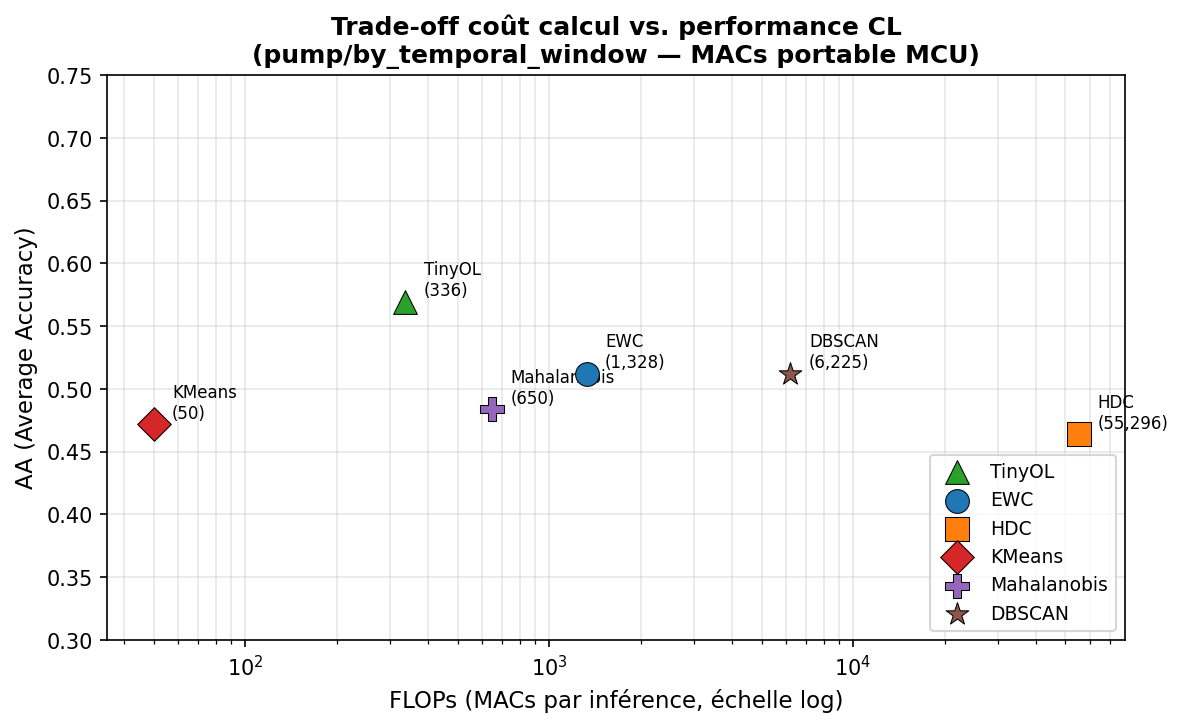

In [7]:
# Section 6b — Scatter FLOPs (MACs) vs. accuracy
# Coût de calcul portable — indépendant de la machine. n_features=25 (stats fenêtrées pump).

kmeans_k = max(1, results["KMeans"]["n_params"] // 25)
dbscan_n_core = max(1, results["DBSCAN"]["n_params"] // 25)

macs = {
    "EWC":         compute_macs("EWC",         n_features=25, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      compute_macs("TinyOL",      n_features=25, encoder_dims=[8, 8, 8], n_classes=1),
    "HDC":         compute_macs("HDC",         n_features=25, dim_hv=2048, n_classes=2),
    "KMeans":      compute_macs("KMeans",      n_features=25, n_clusters=kmeans_k),
    "Mahalanobis": compute_macs("Mahalanobis", n_features=25),
    "DBSCAN":      compute_macs("DBSCAN",      n_features=25, n_core_samples=dbscan_n_core),
}

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    m = macs[name]
    acc = results[name]["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(m, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(f"{name}\n({m:,})", xy=(m, acc), xytext=(m * 1.15, acc + 0.005), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("FLOPs (MACs par inférence, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off coût calcul vs. performance CL\n(pump/by_temporal_window — MACs portable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.30, 0.75)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_flops_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_flops_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_temporal_window/scatter_latency_vs_accuracy.png


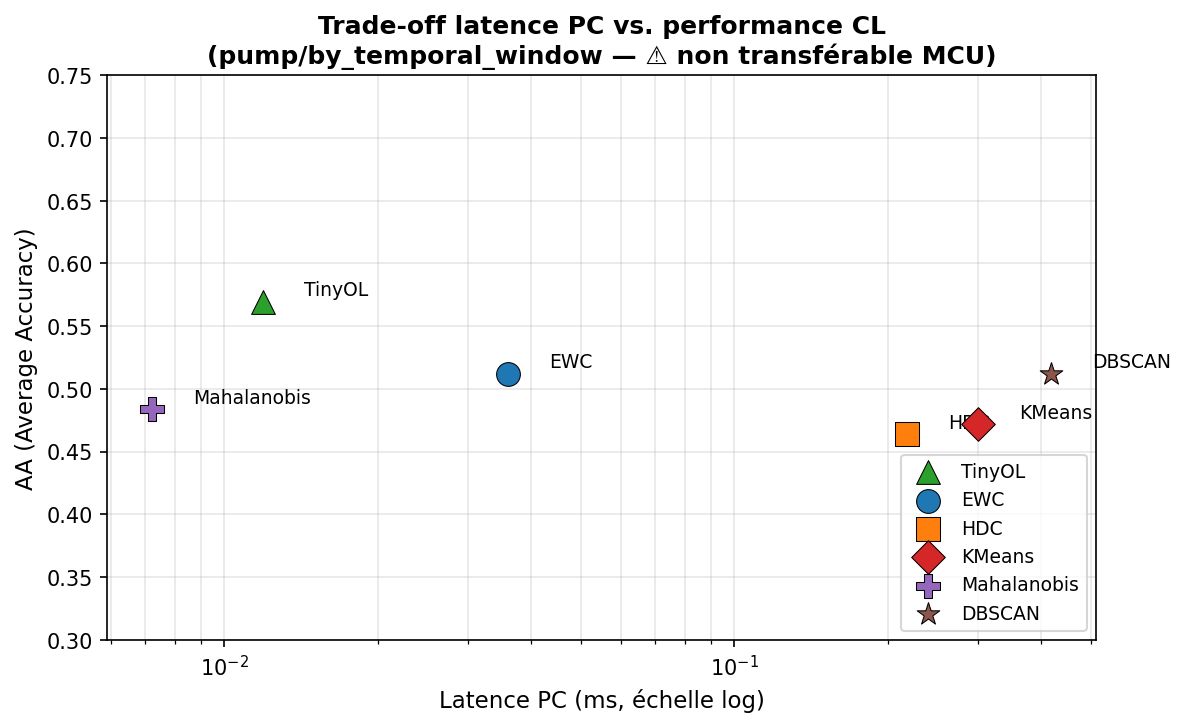

In [8]:
# Section 6c — Scatter latence PC vs. accuracy
# ⚠ Latence mesurée PC — non transférable directement au MCU.

LATENCY_BUDGET_MS = 100.0

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    r = results[name]
    lat = r["inference_latency_ms"]
    acc = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(lat if lat > 0 else 1e-4, acc, marker=marker, color=color, s=130, zorder=5,
               label=name, edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(max(lat, 1e-4), acc), xytext=(max(lat, 1e-4) * 1.2, acc + 0.005),
                fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Latence PC (ms, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off latence PC vs. performance CL\n(pump/by_temporal_window — ⚠ non transférable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.30, 0.75)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_latency_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_latency_vs_accuracy.png")))

In [9]:
# Section 7 — Tableau comparatif complet (6 modèles)

header = "| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |"
sep    = "|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|"
print(header)
print(sep)
rows_md = [header, sep]

for model in MODEL_ORDER:
    r = results[model]
    ram_b = r["ram_peak_bytes"]
    ram_s = f"{ram_b/1024:.1f} Ko{'  ⚠️' if ram_b > RAM_LIMIT else ''}"
    auroc = r["auroc_avg"]
    auroc_s = f"{auroc:.4f}" if isinstance(auroc, (int, float)) else "—"
    n_par = r["n_params"] if r["n_params"] else "—"
    macs_m = macs.get(model, 0)
    line = (
        f"| {model} | {r['aa']:.4f} | {r['af']:.4f} | {r['bwt']:+.4f} | "
        f"{auroc_s} | {ram_s} | {r['inference_latency_ms']:.5f} ms | {n_par} | {macs_m:,} |"
    )
    print(line)
    rows_md.append(line)

display(Markdown("### Tableau récapitulatif — 6 modèles CL (pump/by_temporal_window)\n\n" +
                 "\n".join(rows_md)))

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.5694 | 0.0086 | -0.0086 | — | 5.7 Ko | 0.01193 ms | 1506 | 336 |
| EWC | 0.5121 | 0.0054 | +0.0000 | — | 1.1 Ko | 0.03606 ms | 1377 | 1,328 |
| HDC | 0.4637 | 0.0645 | -0.0591 | — | 14.2 Ko | 0.21850 ms | 2048 | 55,296 |
| KMeans | 0.4718 | 0.0000 | +0.0108 | 0.4260 | 5.7 Ko | 0.30108 ms | 50 | 50 |
| Mahalanobis | 0.4839 | 0.0215 | +0.0161 | 0.4625 | 2.0 Ko | 0.00723 ms | 650 | 650 |
| DBSCAN | 0.5121 | 0.0000 | +0.0000 | 0.4648 | 60.0 Ko | 0.41835 ms | 6225 | 6,225 |


### Tableau récapitulatif — 6 modèles CL (pump/by_temporal_window)

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.5694 | 0.0086 | -0.0086 | — | 5.7 Ko | 0.01193 ms | 1506 | 336 |
| EWC | 0.5121 | 0.0054 | +0.0000 | — | 1.1 Ko | 0.03606 ms | 1377 | 1,328 |
| HDC | 0.4637 | 0.0645 | -0.0591 | — | 14.2 Ko | 0.21850 ms | 2048 | 55,296 |
| KMeans | 0.4718 | 0.0000 | +0.0108 | 0.4260 | 5.7 Ko | 0.30108 ms | 50 | 50 |
| Mahalanobis | 0.4839 | 0.0215 | +0.0161 | 0.4625 | 2.0 Ko | 0.00723 ms | 650 | 650 |
| DBSCAN | 0.5121 | 0.0000 | +0.0000 | 0.4648 | 60.0 Ko | 0.41835 ms | 6225 | 6,225 |

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pump/by_temporal_window/performance_by_temporal_window_bar.png


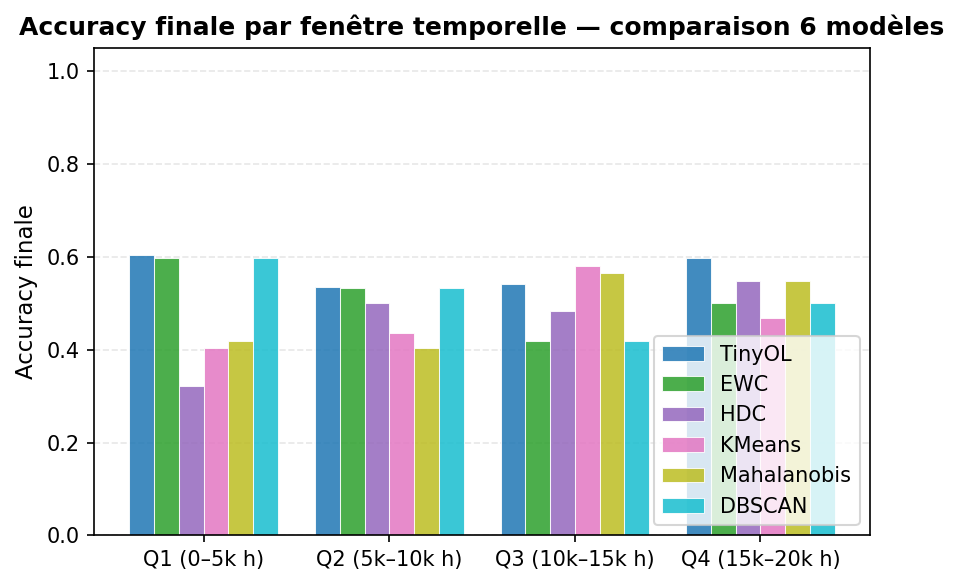

In [10]:
# Section 8 — Performance par fenêtre temporelle (barplot comparaison inter-modèles)
# Spécifique au scénario by_temporal_window : accuracy finale par fenêtre Q1–Q4

results_task = {
    model: {name: float(mat[-1, i]) for i, name in enumerate(TASK_NAMES)}
    for model, mat in acc_matrices.items()
}

fig = plot_performance_by_task_bar(
    results_task,
    task_names=TASK_NAMES,
    title="Accuracy finale par fenêtre temporelle — comparaison 6 modèles",
)
save_figure(fig, FIGURES_DIR / "performance_by_temporal_window_bar.png")
display(Image(str(FIGURES_DIR / "performance_by_temporal_window_bar.png")))

## Discussion — pump/by_temporal_window (4 tâches)

### Pourquoi les performances approchent-elles du hasard (~0.50) ?
Même cause que pour by_pump_id : le feature engineering (25 stats) ne discrimine pas
suffisamment les états de maintenance sur ce dataset. Le drift temporel (dégradation
progressive) pourrait être trop subtil pour les features statistiques actuelles.

### Le scénario temporel est-il plus difficile que by_pump_id (5 tâches) ?
À compléter après exécution. Hypothèse : le drift temporel progressif (dégradation de la
pompe) est plus continu que le drift inter-Pump_ID, rendant les frontières de tâches floues.

### Comparaison by_pump_id vs by_temporal_window
Comparer les métriques AA/AF/BWT entre les deux scénarios pour identifier si le drift
par Pump_ID ou le drift temporel est plus difficile pour les modèles CL.
Cette comparaison est un résultat original (Gap 1).

### Y a-t-il de l'oubli catastrophique sur T1 (Q1) ?
Voir la visualisation Section 5. Pour un scénario de maintenance prédictive, oublier les
patterns de défaut de la phase initiale (Q1, pompe récente) peut être problématique si
les défauts précoces sont différents des défauts tardifs.

### Contrainte RAM STM32N6 (64 Ko)
À compléter après exécution — DBSCAN probablement > 64 Ko (FIXME gap2).

### Questions scientifiques ouvertes
- **FIXME(gap1)** : Le drift temporel progressif (dégradation d'une pompe sur 20k heures)
  est-il représentatif des conditions réelles de maintenance ? Contraster avec FEMTO
  PRONOSTIA (INSA, roulements à billes sous charge contrôlée).
- **FIXME(gap2)** : DBSCAN dépasse probablement 64 Ko — piste buffer borné ou INT8.
- **TODO(arnaud)** : Les AA ≈ 0.50 sur le scénario temporel sont-elles plus faciles à
  expliquer scientifiquement (drift subtil) que les AA ≈ 0.50 sur by_pump_id ?
- **TODO(arnaud)** : Le drift temporel progressif (dégradation 0–20k heures) est-il à
  documenter comme un type de drift différent du drift par type d'équipement (Dataset 2) ?
- **TODO(fred)** : Dans un contexte industriel, les patterns de défaut varient-ils
  significativement entre le début de vie (Q1) et la fin de vie (Q4) d'une pompe ?